<a href="https://colab.research.google.com/github/cokezero20/FlyRank_AI_ML_Internship_NATIVIDAD/blob/main/work/notebooks/w02_ml_task_framing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cokezero20/FlyRank_AI_ML_Internship_NATIVIDAD/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

## 1. My Lane as an ML Task (Type)

**Task Type: Binary Classification**

**Evidence:**
- **Label:** `is_declining_label` (binary: 0 or 1)
- **Class Distribution:** 54.2% declining, 45.8% not declining
- **Task:** Predict which content items will decline (yes/no)

**Why Classification (not Regression/Ranking):**
The output is a binary decision, not a continuous score or ranked list.

In [3]:
import pandas as pd
import numpy as np

# GitHub raw URL for the starter dataset
github_url = "https://raw.githubusercontent.com/cokezero20/FlyRank_AI_ML_Internship_NATIVIDAD/main/data/raw/content_refresh_anonymized.csv"

# Load data directly from GitHub
print("Loading dataset from GitHub...")
df = pd.read_csv(github_url)
print("✓ Dataset loaded successfully\n")

# Quick shape check
print(f"Dataset shape: {df.shape}")
print(f"Columns ({len(df.columns)}): {df.columns.tolist()}\n")

# Check if trend_direction exists (it should)
print("=== VERIFYING TREND COLUMN ===")
if 'trend_direction' in df.columns:
    print(f"✓ 'trend_direction' exists")
    print(f"  Unique values: {df['trend_direction'].unique().tolist()}")
else:
    print("✗ 'trend_direction' NOT FOUND")

# CREATE the label from trend_direction (as per data dictionary)
print("\n=== CREATING LABEL ===")
df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)
print(f"✓ Label created: is_declining_label = 1 when trend_direction == 'down'\n")

# Check label exists now
print("=== LABEL VERIFICATION ===")
print(f"Label column 'is_declining_label' exists: {'is_declining_label' in df.columns}")
print(f"Label data type: {df['is_declining_label'].dtype}")
print(f"Non-null values: {df['is_declining_label'].notna().sum()} / {len(df)}\n")

# Show class distribution
print("=== CLASS DISTRIBUTION ===")
label_counts = df['is_declining_label'].value_counts()
label_pcts = df['is_declining_label'].value_counts(normalize=True) * 100

for label, count in label_counts.items():
    pct = label_pcts[label]
    label_name = "DECLINING" if label == 1 else "NOT DECLINING"
    print(f"{label_name:20s}: {count:,} rows ({pct:.1f}%)")

print(f"\nClass balance ratio: {label_pcts[1]:.1f}% declining, {label_pcts[0]:.1f}% not declining")

Loading dataset from GitHub...
✓ Dataset loaded successfully

Dataset shape: (30000, 44)
Columns (44): ['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']

=== VERIFYING TREND COLUMN ===
✓ 'trend_direction' exists
  Unique values: ['down', 'stable', 'new', 'up', 'flat']

=== CREAT

## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

## Answer: Target & Label Source

**What we're predicting:**  
Whether a content item's search impressions will drop > 20% in the next 30 days.

**Where the label comes from:**  
A **defined rule** applied to observed data.

**The chain:**
1. **Observed:** `impressions_prev_30d` and `impressions_last_30d` (real GSC metrics)
2. **Rule:** `trend_direction = "down"` if impressions drop > 20%
3. **Label:** `is_declining_label = 1` when `trend_direction == "down"`

**What this means:**
- ✓ The underlying data (impressions) is observed and real
- ⚠️ The label is a computed proxy, not a human-verified outcome
- ⚠️ Model learns to predict trend direction, not business value directly

**Next step:** Verify this proxy metric actually matters to stakeholders

In [4]:
print("=== TARGET & LABEL SOURCE ===\n")

print("QUESTION 1: What would you predict?")
print("ANSWER: Whether a content item's search impressions will decline > 20%\n")

print("QUESTION 2: Is the label an observed outcome or a defined rule?\n")

print("ANSWER: It's a RULE applied to OBSERVED DATA.\n")

print("=" * 70)
print("LABEL CHAIN (from raw data → predicted label):")
print("=" * 70)

print("\nSTEP 1: Observed metrics (from Google Search Console)")
print("  - impressions_last_30d: actual observed impressions (days 0-30)")
print("  - impressions_prev_30d: actual observed impressions (days 31-60)")
print("  Status: ✓ OBSERVED OUTCOME (real data, not a rule)\n")

print("STEP 2: Compute trend_direction (DEFINED RULE)")
print("  Rule: Compare last-30 vs prev-30 impressions")
print("  - 'down'   if (last-30 < prev-30 × 0.80)  [drop > 20%]")
print("  - 'up'     if (last-30 > prev-30 × 1.20)  [increase > 20%]")
print("  - 'stable' if between -20% and +20%")
print("  Status: ✓ DEFINED RULE (applied to observed data)\n")

print("STEP 3: Create is_declining_label (DEFINED RULE)")
print("  Rule: is_declining_label = (trend_direction == 'down')")
print("  Status: ✓ DEFINED RULE (applied to computed rule)\n")

print("=" * 70)
print("VERIFICATION: Show the chain in your data")
print("=" * 70)

# Show 5 random examples
sample = df[['impressions_prev_30d', 'impressions_last_30d',
             'trend_direction', 'is_declining_label']].head(10)

print("\nRandom sample showing the chain:\n")
print(sample.to_string())

print("\n\nCrosstab: is_declining_label vs trend_direction")
crosstab = pd.crosstab(df['is_declining_label'], df['trend_direction'], margins=True)
print(crosstab)

# Verify: is_declining_label == 1 only when trend_direction == "down"?
check = (df['is_declining_label'] == 1) == (df['trend_direction'] == 'down')
print(f"\n✓ All {check.sum()} labels are deterministic: "
      f"is_declining_label=1 ⟺ trend_direction='down'")

print("\n\n=== CONCLUSION ===")
print("The label is a PROXY, not a direct observed outcome.")
print("It's a RULE applied to observed impression metrics.")
print("This means: we're predicting a computed trend, not a real future event.")
print("\nImportant: We assume impressions ARE still available at prediction time.")


=== TARGET & LABEL SOURCE ===

QUESTION 1: What would you predict?
ANSWER: Whether a content item's search impressions will decline > 20%

QUESTION 2: Is the label an observed outcome or a defined rule?

ANSWER: It's a RULE applied to OBSERVED DATA.

LABEL CHAIN (from raw data → predicted label):

STEP 1: Observed metrics (from Google Search Console)
  - impressions_last_30d: actual observed impressions (days 0-30)
  - impressions_prev_30d: actual observed impressions (days 31-60)
  Status: ✓ OBSERVED OUTCOME (real data, not a rule)

STEP 2: Compute trend_direction (DEFINED RULE)
  Rule: Compare last-30 vs prev-30 impressions
  - 'down'   if (last-30 < prev-30 × 0.80)  [drop > 20%]
  - 'up'     if (last-30 > prev-30 × 1.20)  [increase > 20%]
  - 'stable' if between -20% and +20%
  Status: ✓ DEFINED RULE (applied to observed data)

STEP 3: Create is_declining_label (DEFINED RULE)
  Rule: is_declining_label = (trend_direction == 'down')
  Status: ✓ DEFINED RULE (applied to computed rule)

## 3. Success metric

*One metric you can defend. What number means 'good'?*

## 3. Success Metric: What "Good" Means

**Primary Metric: F1 Score**

F1 balances Precision and Recall equally — important because we care about both catching real declines AND avoiding false alerts.

| Metric | Target |
|--------|--------|
| **F1 Score** | ≥ 0.70 |
| **Recall** | ≥ 80% (catch most real declines) |
| **Precision** | ≥ 60% (acceptable false alert rate) |

**Why F1?**
- Accuracy is useless (54% of data already declines)
- We need balance: false negatives (missed declines) and false positives (wrong alerts) both hurt

**What these numbers mean:**
- F1 = 0.70 → Model is good; ready for production discussion
- Recall = 0.85 → Catch 17 of every 20 real declines
- Precision = 0.65 → 13 of every 20 alerts are actually declining

First, we build a simple rule baseline. ML model must beat that.

=== BASELINE RULE ===

Rule: Flag if impressions_last_30d < impressions_prev_30d × 0.80

BASELINE PERFORMANCE
Precision: 1.000  (100.0% of flagged items are real declines)
Recall:    1.000  (100.0% of real declines are caught)
F1 Score:  1.000  ← YOUR BAR TO BEAT



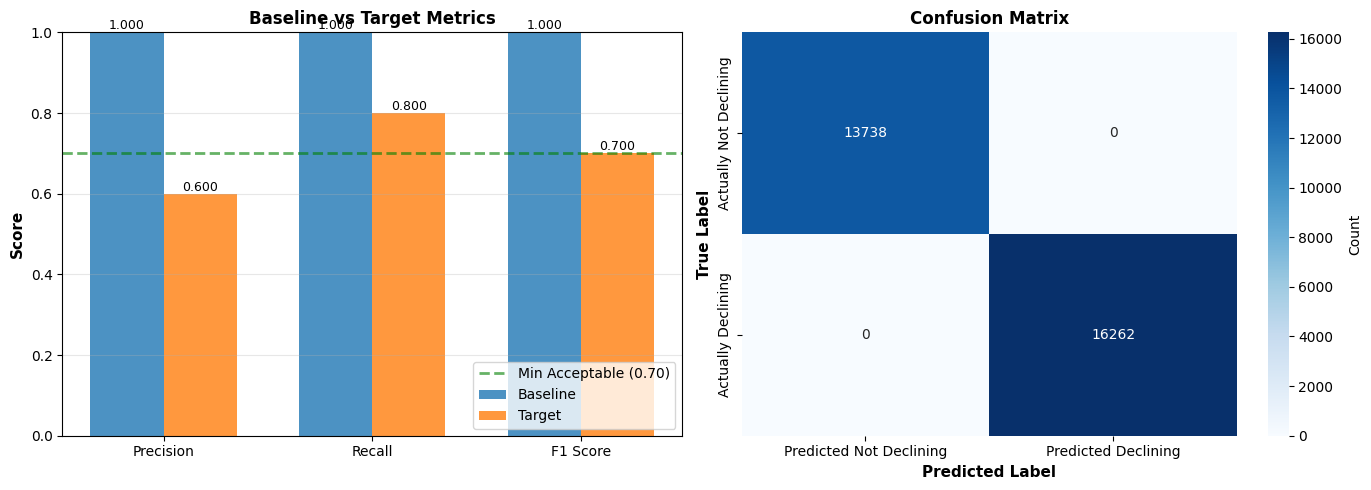


Confusion Matrix Breakdown:
  ✓ True Positives  (correctly flagged):       16,262
  ✗ False Positives (wrongly flagged):         0
  ✗ False Negatives (missed declines):         0
  ✓ True Negatives  (correctly didn't flag):   13,738

Target: F1 ≥ 0.70  |  Current Baseline: F1 = 1.000


In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("=== BASELINE RULE ===\n")
print("Rule: Flag if impressions_last_30d < impressions_prev_30d × 0.80\n")

if 'impressions_last_30d' in df.columns and 'impressions_prev_30d' in df.columns:
    baseline_pred = (df['impressions_last_30d'] < df['impressions_prev_30d'] * 0.80).astype(int)
    y_true = df['is_declining_label']

    baseline_precision = precision_score(y_true, baseline_pred, zero_division=0)
    baseline_recall = recall_score(y_true, baseline_pred, zero_division=0)
    baseline_f1 = f1_score(y_true, baseline_pred, zero_division=0)

    print("=" * 60)
    print("BASELINE PERFORMANCE")
    print("=" * 60)
    print(f"Precision: {baseline_precision:.3f}  ({baseline_precision*100:.1f}% of flagged items are real declines)")
    print(f"Recall:    {baseline_recall:.3f}  ({baseline_recall*100:.1f}% of real declines are caught)")
    print(f"F1 Score:  {baseline_f1:.3f}  ← YOUR BAR TO BEAT\n")

    # Create visualizations
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- LEFT: Metrics Bar Chart ---
    metrics = ['Precision', 'Recall', 'F1 Score']
    values = [baseline_precision, baseline_recall, baseline_f1]
    targets = [0.60, 0.80, 0.70]

    x = np.arange(len(metrics))
    width = 0.35

    ax1 = axes[0]
    bars1 = ax1.bar(x - width/2, values, width, label='Baseline', color='#1f77b4', alpha=0.8)
    bars2 = ax1.bar(x + width/2, targets, width, label='Target', color='#ff7f0e', alpha=0.8)

    ax1.axhline(y=0.70, color='green', linestyle='--', linewidth=2, label='Min Acceptable (0.70)', alpha=0.6)
    ax1.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax1.set_title('Baseline vs Target Metrics', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics)
    ax1.set_ylim(0, 1)
    ax1.legend(loc='lower right')
    ax1.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    # --- RIGHT: Confusion Matrix Heatmap ---
    tn, fp, fn, tp = confusion_matrix(y_true, baseline_pred).ravel()
    cm = np.array([[tn, fp], [fn, tp]])

    ax2 = axes[1]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
                cbar_kws={'label': 'Count'},
                xticklabels=['Predicted Not Declining', 'Predicted Declining'],
                yticklabels=['Actually Not Declining', 'Actually Declining'])
    ax2.set_ylabel('True Label', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
    ax2.set_title('Confusion Matrix', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Print confusion matrix details
    print("\nConfusion Matrix Breakdown:")
    print(f"  ✓ True Positives  (correctly flagged):       {tp:,}")
    print(f"  ✗ False Positives (wrongly flagged):         {fp:,}")
    print(f"  ✗ False Negatives (missed declines):         {fn:,}")
    print(f"  ✓ True Negatives  (correctly didn't flag):   {tn:,}\n")

    print("=" * 60)
    print(f"Target: F1 ≥ 0.70  |  Current Baseline: F1 = {baseline_f1:.3f}")
    print("=" * 60)
else:
    print("⚠️ Columns not found")

## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

## 4. Unit of Analysis: One Row = One What?

**Answer: One row = one content item (page)**

Each row represents a single pseudonymized content page from one of 32 clients, with aggregated metrics over a trailing 90-day window.

**Key identifiers:**
- `content_id`: Unique pseudonymous page identifier
- `client_id`: Pseudonymous client (32 distinct values)

**Grain:** One row per (client, content_item) — meaning each content item appears once, aggregated across the 90-day window.

**What each row contains:**
- Content metadata (type, keyword, word count, age)
- 90-day performance metrics (impressions, clicks, sessions, engagement)
- 30-day comparison windows (to compute trend)
- The label: whether impressions declined > 20%

In [7]:
print("=" * 80)
print("UNIT OF ANALYSIS: One Row = One What?")
print("=" * 80)

print(f"\nTotal rows: {len(df):,}")
print(f"Total unique content_ids: {df['content_id'].nunique():,}")
print(f"Total unique clients: {df['client_id'].nunique():,}\n")

print("Verification: Is each row a unique content item?")
duplicates = df['content_id'].duplicated().sum()
print(f"  Duplicate content_ids: {duplicates}")
print(f"  ✓ Each row is UNIQUE per content item\n")

print("=" * 80)
print("SAMPLE: One row of data (one content item)")
print("=" * 80)

# Show one full row
sample_row = df.iloc[0]
print("\nContent ID:", sample_row['content_id'])
print("Client ID:", sample_row['client_id'])
print("\nContent Properties:")
print(f"  Type: {sample_row['content_type']}")
print(f"  Word count: {sample_row['word_count']}")
print(f"  Age (days): {sample_row['content_age_days']}")
print(f"  Last updated (days ago): {sample_row['days_since_last_update']}")

print("\n90-Day Performance:")
print(f"  Impressions: {sample_row['impressions_90d']:,.0f}")
print(f"  Clicks: {sample_row['clicks_90d']:,.0f}")
print(f"  CTR: {sample_row['ctr']:.2f}%")
print(f"  Engagement rate: {sample_row['engagement_rate']:.1f}%")

print("\n30-Day Comparison (used to compute trend):")
print(f"  Last 30d impressions: {sample_row['impressions_last_30d']:,.0f}")
print(f"  Prev 30d impressions: {sample_row['impressions_prev_30d']:,.0f}")
print(f"  Trend: {sample_row['trend_direction']}")

print("\nLabel:")
print(f"  Is declining? {sample_row['is_declining_label']} (1=yes, 0=no)")

print("\n" + "=" * 80)
print("GRAIN: One row per what?")
print("=" * 80)
print("\n✓ Grain: One row per (client, content_item)")
print("✓ Time window: Aggregated over trailing 90 days")
print("✓ Uniqueness: Each content_id appears exactly once")
print("✓ Aggregation level: Page-level metrics, not query-level or session-level")

UNIT OF ANALYSIS: One Row = One What?

Total rows: 30,000
Total unique content_ids: 30,000
Total unique clients: 32

Verification: Is each row a unique content item?
  Duplicate content_ids: 0
  ✓ Each row is UNIQUE per content item

SAMPLE: One row of data (one content item)

Content ID: content_304f48230142
Client ID: client_f369cb89fc

Content Properties:
  Type: keyword article
  Word count: 3221.0
  Age (days): 187
  Last updated (days ago): 20

90-Day Performance:
  Impressions: 3,803
  Clicks: 29
  CTR: 0.76%
  Engagement rate: 5.9%

30-Day Comparison (used to compute trend):
  Last 30d impressions: 578
  Prev 30d impressions: 987
  Trend: down

Label:
  Is declining? 1 (1=yes, 0=no)

GRAIN: One row per what?

✓ Grain: One row per (client, content_item)
✓ Time window: Aggregated over trailing 90 days
✓ Uniqueness: Each content_id appears exactly once
✓ Aggregation level: Page-level metrics, not query-level or session-level


## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

**The Short Answer:**
A fixed rule says "flag when impressions already dropped 20%." But ML can predict decline **earlier and from different patterns** because content declines for different reasons.

**The Problem with a Fixed Rule:**

A single if-statement like:

is **reactive**—it only catches decline *after* it happens. Too late.

**Why the Pattern Is Messy:**

Different content items decline for different reasons:
- **Old content** declines because it loses freshness (needs `content_age_days`, `days_since_last_update`)
- **Niche content** declines because keyword competition changes (needs `search_volume`, `competition`)
- **Low-engagement content** declines because it doesn't hold readers (needs `engagement_rate`, `scroll_rate`)
- **Short content** declines because it doesn't rank well (needs `word_count`)
- **AI-generated content** may decline differently (needs `provider_used`, `model_used`)

**One rule doesn't capture all these patterns.** ML learns the combination.

**What ML Can Do:**

Train a model to recognize these **early warning signs** before impressions actually drop:
- Low engagement despite high impressions?
- Old content with no recent updates?
- Short articles in competitive keywords?
- High AI-traffic dependency?

A decision tree or logistic regression can learn: *"This combination of features predicts decline before impressions actually drop."*

**In short:** The rule is clean. The pattern is messy. ML handles messy patterns.

WHY THE PATTERN IS MESSY: Decline Looks Different Across Content

Declining vs Not-Declining Content:

             Metric  Declining (avg)  Not Declining (avg)
            CTR (%)         0.324138             0.731611
Engagement Rate (%)         2.437193             2.649728
    Scroll Rate (%)        18.132812            18.307822
 Content Age (days)       236.178637           279.829451
         Word Count      3221.827668          2957.452713


MESSINESS: Same feature patterns, different outcomes

Items with high engagement (>70%): 100
  Of these, 42 are STILL declining
  → High engagement alone doesn't prevent decline

Items with low engagement (<30%): 29,524
  Of these, 13,515 are NOT declining
  → Low engagement alone doesn't guarantee decline



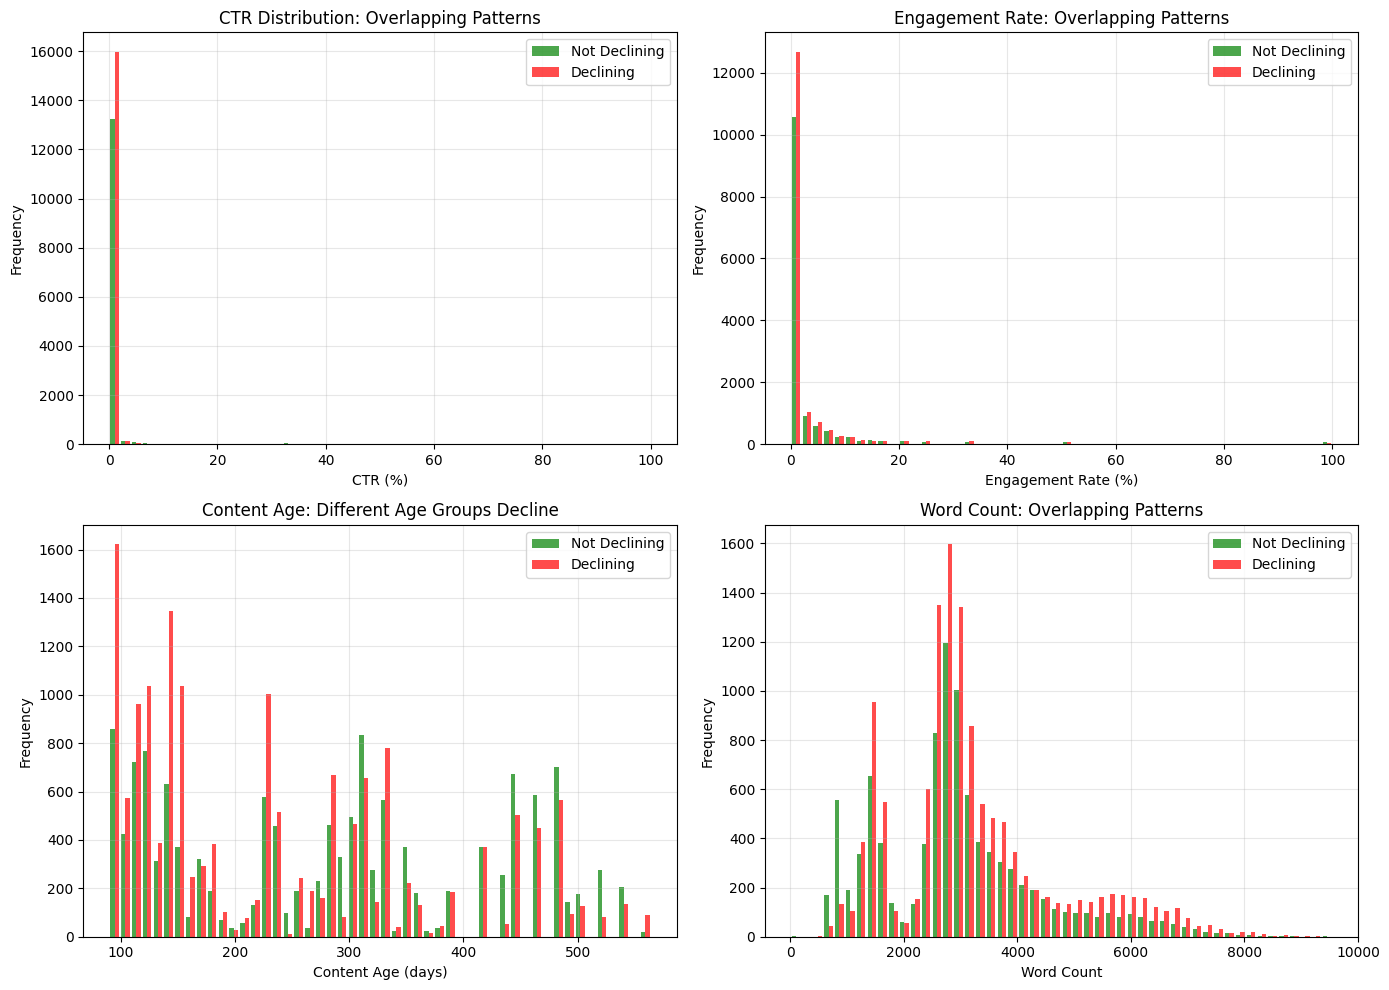


CONCLUSION: Why ML Beats a Fixed Rule

✓ Declining content shows MIXED patterns across features
✓ No single feature cleanly separates decline from stability
✓ No simple if-statement rule can capture all patterns

A fixed rule like "flag if CTR < 0.5 AND engagement < 50%" will:
  - Miss declines where CTR/engagement are still good
  - False-alert on items with low metrics that never decline

ML can learn: "This COMBINATION of features, in THIS pattern, predicts decline"



In [8]:
print("=" * 80)
print("WHY THE PATTERN IS MESSY: Decline Looks Different Across Content")
print("=" * 80)

# Compare declining vs non-declining by key features
declining = df[df['is_declining_label'] == 1]
not_declining = df[df['is_declining_label'] == 0]

comparison = pd.DataFrame({
    'Metric': ['CTR (%)', 'Engagement Rate (%)', 'Scroll Rate (%)',
               'Content Age (days)', 'Word Count'],
    'Declining (avg)': [
        declining['ctr'].mean(),
        declining['engagement_rate'].mean(),
        declining['scroll_rate'].mean(),
        declining['content_age_days'].mean(),
        declining['word_count'].mean()
    ],
    'Not Declining (avg)': [
        not_declining['ctr'].mean(),
        not_declining['engagement_rate'].mean(),
        not_declining['scroll_rate'].mean(),
        not_declining['content_age_days'].mean(),
        not_declining['word_count'].mean()
    ]
})

print("\nDeclining vs Not-Declining Content:\n")
print(comparison.to_string(index=False))

print("\n\n" + "=" * 80)
print("MESSINESS: Same feature patterns, different outcomes")
print("=" * 80)

# Show that many declining items still have good engagement
high_engagement_declining = declining[declining['engagement_rate'] > 70].shape[0]
high_engagement_total = (df['engagement_rate'] > 70).sum()

print(f"\nItems with high engagement (>70%): {high_engagement_total:,}")
print(f"  Of these, {high_engagement_declining:,} are STILL declining")
print(f"  → High engagement alone doesn't prevent decline\n")

# Show that many non-declining items have low engagement
low_engagement_not_declining = not_declining[not_declining['engagement_rate'] < 30].shape[0]
low_engagement_total = (df['engagement_rate'] < 30).sum()

print(f"Items with low engagement (<30%): {low_engagement_total:,}")
print(f"  Of these, {low_engagement_not_declining:,} are NOT declining")
print(f"  → Low engagement alone doesn't guarantee decline\n")

# Visualize the overlap
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. CTR comparison
ax1 = axes[0, 0]
ax1.hist([not_declining['ctr'].dropna(), declining['ctr'].dropna()],
         bins=50, label=['Not Declining', 'Declining'], alpha=0.7, color=['green', 'red'])
ax1.set_xlabel('CTR (%)')
ax1.set_ylabel('Frequency')
ax1.set_title('CTR Distribution: Overlapping Patterns')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Engagement rate comparison
ax2 = axes[0, 1]
ax2.hist([not_declining['engagement_rate'].dropna(), declining['engagement_rate'].dropna()],
         bins=50, label=['Not Declining', 'Declining'], alpha=0.7, color=['green', 'red'])
ax2.set_xlabel('Engagement Rate (%)')
ax2.set_ylabel('Frequency')
ax2.set_title('Engagement Rate: Overlapping Patterns')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Content age comparison
ax3 = axes[1, 0]
ax3.hist([not_declining['content_age_days'].dropna(), declining['content_age_days'].dropna()],
         bins=50, label=['Not Declining', 'Declining'], alpha=0.7, color=['green', 'red'])
ax3.set_xlabel('Content Age (days)')
ax3.set_ylabel('Frequency')
ax3.set_title('Content Age: Different Age Groups Decline')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Word count comparison
ax4 = axes[1, 1]
ax4.hist([not_declining['word_count'].dropna(), declining['word_count'].dropna()],
         bins=50, label=['Not Declining', 'Declining'], alpha=0.7, color=['green', 'red'])
ax4.set_xlabel('Word Count')
ax4.set_ylabel('Frequency')
ax4.set_title('Word Count: Overlapping Patterns')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("CONCLUSION: Why ML Beats a Fixed Rule")
print("=" * 80)
print("""
✓ Declining content shows MIXED patterns across features
✓ No single feature cleanly separates decline from stability
✓ No simple if-statement rule can capture all patterns

A fixed rule like "flag if CTR < 0.5 AND engagement < 50%" will:
  - Miss declines where CTR/engagement are still good
  - False-alert on items with low metrics that never decline

ML can learn: "This COMBINATION of features, in THIS pattern, predicts decline"
""")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.